In [3]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

import seaborn as sns
import torch
import numpy as np
from torch.optim.lr_scheduler import SequentialLR, LinearLR, CosineAnnealingLR


from common.data import DataWithLabels


In [21]:
dataset = DataWithLabels.from_npz(r'data/monte_carlo_configs.npz')

X              = dataset.x
Values         = dataset.values
Configurations = dataset.configurations
Energies       = dataset.energies
Labels         = dataset.labels

## Contrastive Learning

Epoch 1/100, Average Loss: 0.205360, Average Val Loss: 0.108474
Epoch 2/100, Average Loss: 0.139944, Average Val Loss: 0.066072
Epoch 3/100, Average Loss: 0.090004, Average Val Loss: 0.044734
Epoch 4/100, Average Loss: 0.074767, Average Val Loss: 0.039863


c:\Users\Vít\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\optim\lr_scheduler.py:240: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  warnings.warn(EPOCH_DEPRECATION_WARNING, UserWarning)


Epoch 5/100, Average Loss: 0.068300, Average Val Loss: 0.035931
Epoch 6/100, Average Loss: 0.058606, Average Val Loss: 0.030540
Epoch 7/100, Average Loss: 0.054454, Average Val Loss: 0.026263
Epoch 8/100, Average Loss: 0.048743, Average Val Loss: 0.023212
Epoch 9/100, Average Loss: 0.043595, Average Val Loss: 0.024963
Epoch 10/100, Average Loss: 0.040262, Average Val Loss: 0.022441
Epoch 11/100, Average Loss: 0.038179, Average Val Loss: 0.019275
Epoch 12/100, Average Loss: 0.036234, Average Val Loss: 0.014922
Epoch 13/100, Average Loss: 0.034269, Average Val Loss: 0.015512
Epoch 14/100, Average Loss: 0.033318, Average Val Loss: 0.013898
Epoch 15/100, Average Loss: 0.029941, Average Val Loss: 0.013382
Epoch 16/100, Average Loss: 0.029324, Average Val Loss: 0.012149
Epoch 17/100, Average Loss: 0.030846, Average Val Loss: 0.013458
Epoch 18/100, Average Loss: 0.028126, Average Val Loss: 0.009979
Epoch 19/100, Average Loss: 0.029463, Average Val Loss: 0.008566
Epoch 20/100, Average Loss: 0.

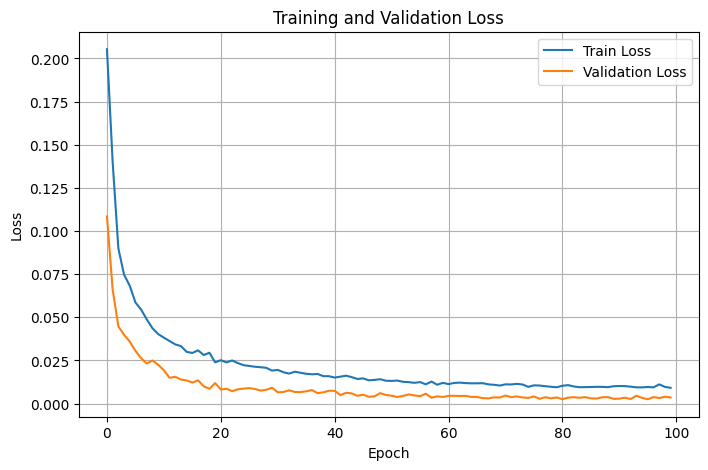

Embeddings shape: (6000, 2)


In [5]:
from contrastive_learning.model import SiameseNetwork, TrainConfig, train_model, get_embeddings
from contrastive_learning.dataset import make_balanced_train_test_dataset
from common.utils import plot_loss_curves

num_epochs = 100
warmup_epochs = max(1, int(0.05 * num_epochs))
EMBEDDING_SIZE = 2
train_loader, test_loader = make_balanced_train_test_dataset(
    Configurations, Labels, 
    batch_size=64, 
    train_ratio=0.8, 
    positive_ratio=0.5
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
train = True
save_model = True
save_dir = Path('results')
if train:
    model = SiameseNetwork(embedding_size=EMBEDDING_SIZE).to(device)

    optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
    sched1 = LinearLR(optimizer, start_factor=1e-3, end_factor=1.0, total_iters=warmup_epochs)
    sched2 = CosineAnnealingLR(optimizer, T_max=(num_epochs - warmup_epochs))
    scheduler = SequentialLR(optimizer, schedulers=[sched1, sched2], milestones=[warmup_epochs])

    config = TrainConfig(
        device=device,
        model=model,
        optimizer=optimizer,
        scheduler=scheduler,
        train_loader=train_loader,
        test_loader=test_loader,
    )

    avg_loss, avg_val_loss = train_model(config, num_epochs=num_epochs, steps_per_epoch=50, margin=1.0)
    plot_loss_curves(avg_loss, avg_val_loss)
    if save_model:
        torch.save({
            'model_state_dict': model.state_dict(),
            'embedding_size': EMBEDDING_SIZE,
        }, save_dir / 'siamese_encoder.pt')
else:
    checkpoint = torch.load(save_dir / 'siamese_encoder.pt', map_location=device, weights_only=True)

    model = SiameseNetwork(embedding_size=checkpoint['embedding_size']).to(device)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()

    config = TrainConfig(
        device=device,
        model=model,
        optimizer=None,
        scheduler=None,
        train_loader=None,
        test_loader=None,
    )

# Get embeddings for all configurations
all_embeddings = get_embeddings(config, Configurations)
print(f"Embeddings shape: {all_embeddings.shape}")

***

## Clustering

here, we shall cluster samples in the embedding space and compare to the original clustering.

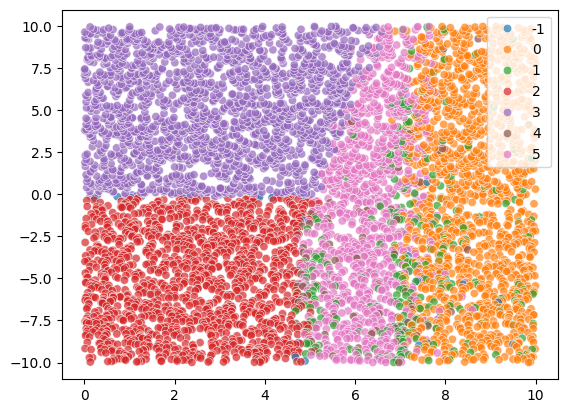

In [6]:
from hdbscan import HDBSCAN

hd_contr = HDBSCAN(min_cluster_size=30, cluster_selection_epsilon=0.018, cluster_selection_method='eom').fit(all_embeddings)
Labels_contr = hd_contr.labels_

ax = sns.scatterplot(x=Values[:, 1], y=Values[:, 0], hue=Labels_contr, palette='tab10', alpha=0.7)

In [7]:
data_optimized = DataWithLabels.from_npz('data/configs_grad.npz')
embeddings_optimized = get_embeddings(config, data_optimized.configurations)

<Axes: >

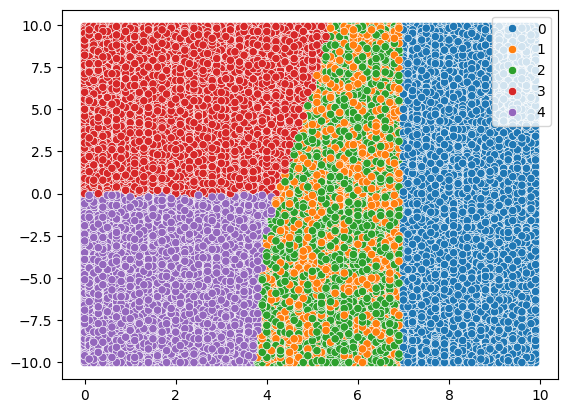

In [15]:
hd_grad = HDBSCAN(min_cluster_size=30, cluster_selection_epsilon=0.15, cluster_selection_method='eom').fit(embeddings_optimized)
Labels_grad = hd_grad.labels_

Values_grad = data_optimized.values
sns.scatterplot(x=Values_grad[:, 1], y=Values_grad[:, 0], hue=Labels_grad, palette='tab10')

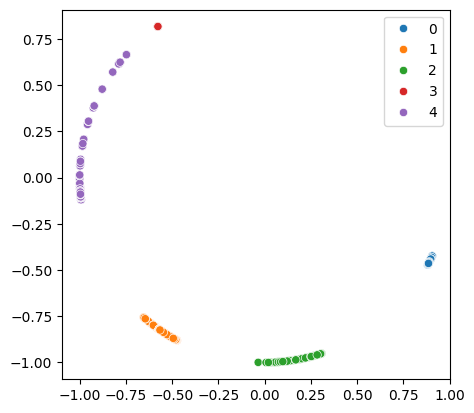

In [18]:
ax = sns.scatterplot(x=embeddings_optimized[:, 0], y=embeddings_optimized[:, 1], hue=Labels_grad, palette='tab10')
ax.set_aspect('equal')